In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/demand_forecasting_dataset.csv")

df.head()

,date,day_of_week,is_weekend,month,is_holiday_or_festival,zone_id,zone_name,zone_density_tier,service_type,price_tier,weather_condition,temperature_c,num_available_workers,avg_zone_worker_rating,promo_active,past_7day_avg_bookings,avg_response_time_min,cancellation_rate,bookings_demand
0,2023-01-01,Sunday,1,1,0,Z01,Riverside Sector,High,Babysitting/Childcare,Medium,Sunny,30.8,7,3.68,0,0.00,41.2,0.030,4
1,2023-01-02,Monday,0,1,0,Z01,Riverside Sector,High,Babysitting/Childcare,Medium,Foggy,8.9,11,3.68,0,4.00,30.8,0.055,1
2,2023-01-03,Tuesday,0,1,0,Z01,Riverside Sector,High,Babysitting/Childcare,Medium,Foggy,12.4,23,3.68,0,2.50,14.6,0.078,1
3,2023-01-04,Wednesday,0,1,0,Z01,Riverside Sector,High,Babysitting/Childcare,Medium,Foggy,13.2,16,3.68,0,2.00,14.6,0.050,1
4,2023-01-05,Thursday,0,1,0,Z01,Riverside Sector,High,Babysitting/Childcare,Medium,Foggy,13.1,19,3.68,0,1.75,19.1,0.060,1


In [55]:
df.shape


(58400, 19)

In [56]:
df.columns

Index(['date', 'day_of_week', 'is_weekend', 'month', 'is_holiday_or_festival',
       'zone_id', 'zone_name', 'zone_density_tier', 'service_type',
       'price_tier', 'weather_condition', 'temperature_c',
       'num_available_workers', 'avg_zone_worker_rating', 'promo_active',
       'past_7day_avg_bookings', 'avg_response_time_min', 'cancellation_rate',
       'bookings_demand'],
      dtype='str')

In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 58400 entries, 0 to 58399
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    58400 non-null  str    
 1   day_of_week             58400 non-null  str    
 2   is_weekend              58400 non-null  int64  
 3   month                   58400 non-null  int64  
 4   is_holiday_or_festival  58400 non-null  int64  
 5   zone_id                 58400 non-null  str    
 6   zone_name               58400 non-null  str    
 7   zone_density_tier       58400 non-null  str    
 8   service_type            58400 non-null  str    
 9   price_tier              58400 non-null  str    
 10  weather_condition       58400 non-null  str    
 11  temperature_c           58400 non-null  float64
 12  num_available_workers   58400 non-null  int64  
 13  avg_zone_worker_rating  58400 non-null  float64
 14  promo_active            58400 non-null  int64  
 

In [58]:
df.isnull().sum()

date                      0
day_of_week               0
is_weekend                0
month                     0
is_holiday_or_festival    0
zone_id                   0
zone_name                 0
zone_density_tier         0
service_type              0
price_tier                0
weather_condition         0
temperature_c             0
num_available_workers     0
avg_zone_worker_rating    0
promo_active              0
past_7day_avg_bookings    0
avg_response_time_min     0
cancellation_rate         0
bookings_demand           0
dtype: int64

In [59]:
df.duplicated().sum()

np.int64(0)

In [60]:
df['bookings_demand'].describe()

count    58400.000000
mean         2.179521
std          1.923893
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         18.000000
Name: bookings_demand, dtype: float64

In [61]:
df["date"] = pd.to_datetime(df["date"])

print("Date range:")
print(df["date"].min(), "to", df["date"].max())

print("\nZones:")
print(df["zone_name"].nunique())
print(df["zone_name"].unique())

print("\nServices:")
print(df["service_type"].nunique())
print(df["service_type"].unique())

Date range:
2023-01-01 00:00:00 to 2024-12-30 00:00:00

Zones:
10
<ArrowStringArray>
[     'Riverside Sector',       'Old Town Market',     'Tech Park Enclave',
         'Green Meadows',       'Hillview Colony',       'Industrial Belt',
   'University Township',    'Lakeside Residency', 'Central Business Dist',
    'Suburban Extension']
Length: 10, dtype: str

Services:
8
<ArrowStringArray>
['Babysitting/Childcare',      'Cooking/Catering',          'Elderly Care',
     'Electrical Repair', 'Gardening/Landscaping',         'Home Cleaning',
       'Laundry/Ironing',       'Plumbing Repair']
Length: 8, dtype: str


In [62]:
service_demand = (
    df.groupby("service_type")["bookings_demand"]
    .agg(["mean", "sum", "max"])
    .sort_values("mean", ascending=False)
)

service_demand

,mean,sum,max
service_type,,,
Home Cleaning,3.938493,28751,18
Laundry/Ironing,2.746301,20048,15
Babysitting/Childcare,2.396712,17496,15
Plumbing Repair,2.285479,16684,14
Cooking/Catering,1.847123,13484,13
Electrical Repair,1.806712,13189,10
Elderly Care,1.242329,9069,8
Gardening/Landscaping,1.173014,8563,7


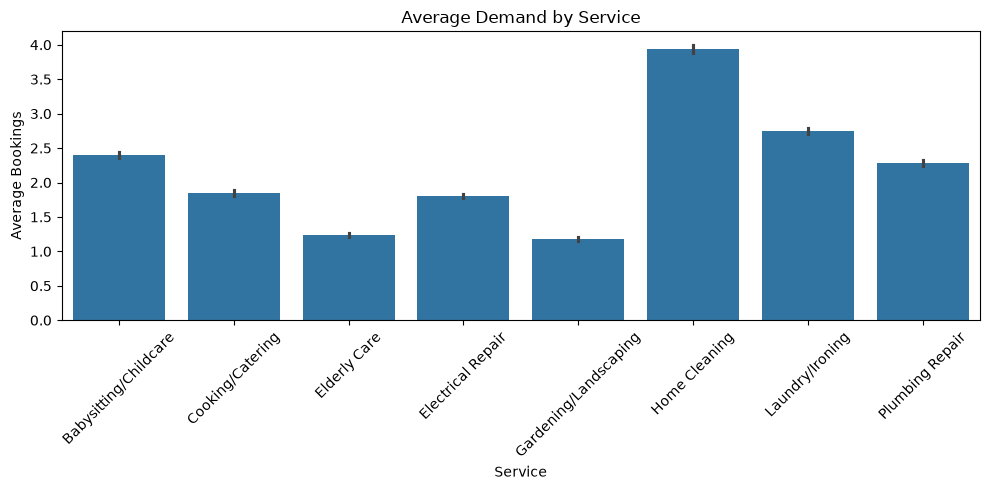

In [63]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="service_type",
    y="bookings_demand",
    estimator="mean"
)

plt.xticks(rotation=45)
plt.title("Average Demand by Service")
plt.xlabel("Service")
plt.ylabel("Average Bookings")
plt.tight_layout()
plt.show()

In [64]:
weekday_demand = (
    df.groupby("day_of_week")["bookings_demand"]
    .mean()
)

weekday_demand

day_of_week
Friday       1.939663
Monday       1.958690
Saturday     2.737260
Sunday       2.737500
Thursday     1.942067
Tuesday      1.968750
Wednesday    1.969471
Name: bookings_demand, dtype: float64

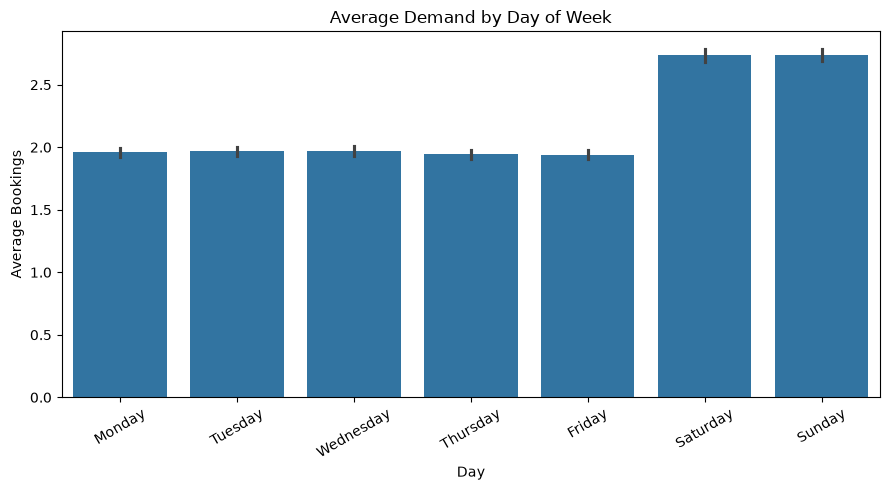

In [65]:
order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="day_of_week",
    y="bookings_demand",
    order=order,
    estimator="mean"
)

plt.title("Average Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Bookings")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [66]:
monthly_demand = (
    df.groupby("month")["bookings_demand"]
    .mean()
)

monthly_demand

month
1     1.991129
2     1.975658
3     2.296774
4     2.006458
5     2.021976
6     2.090000
7     2.247177
8     2.289919
9     2.253125
10    2.496371
11    2.217083
12    2.248361
Name: bookings_demand, dtype: float64

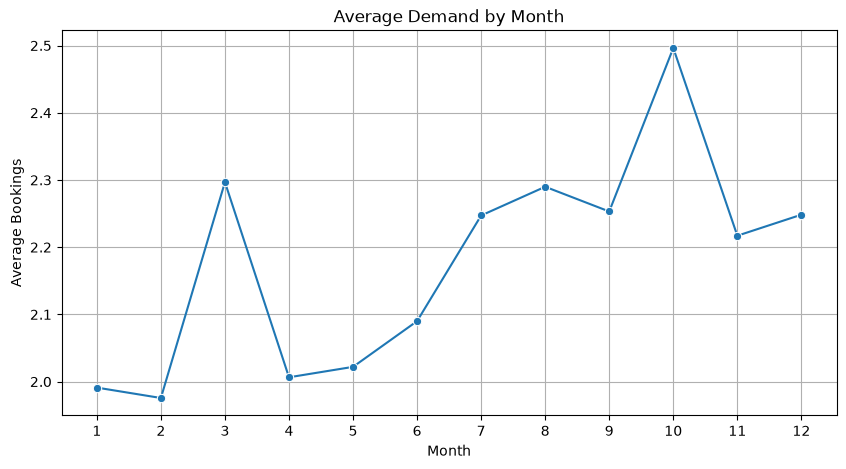

In [67]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=monthly_demand.index,
    y=monthly_demand.values,
    marker="o"
)

plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Bookings")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

In [68]:
# ==========================================
# FEATURE RELATIONSHIPS
# ==========================================

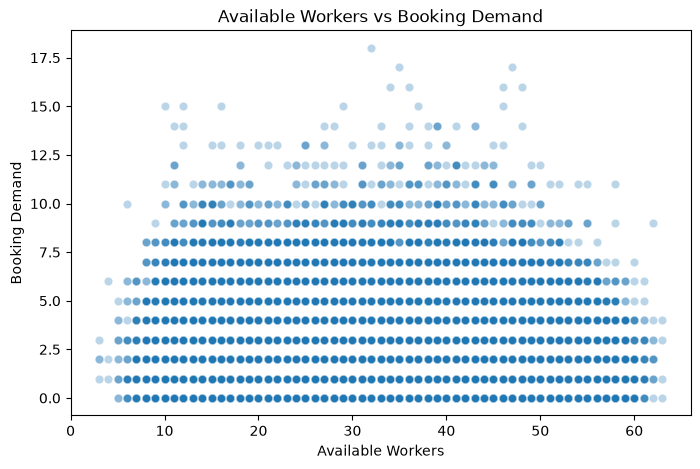

In [69]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="num_available_workers",
    y="bookings_demand",
    alpha=0.3
)

plt.title("Available Workers vs Booking Demand")
plt.xlabel("Available Workers")
plt.ylabel("Booking Demand")
plt.show()

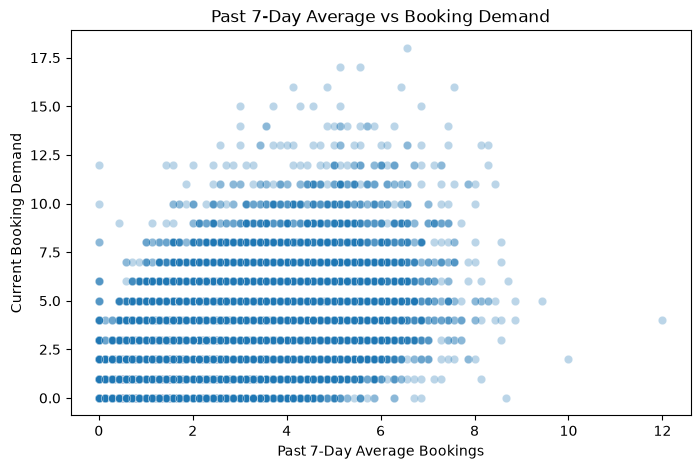

In [70]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="past_7day_avg_bookings",
    y="bookings_demand",
    alpha=0.3
)

plt.title("Past 7-Day Average vs Booking Demand")
plt.xlabel("Past 7-Day Average Bookings")
plt.ylabel("Current Booking Demand")
plt.show()

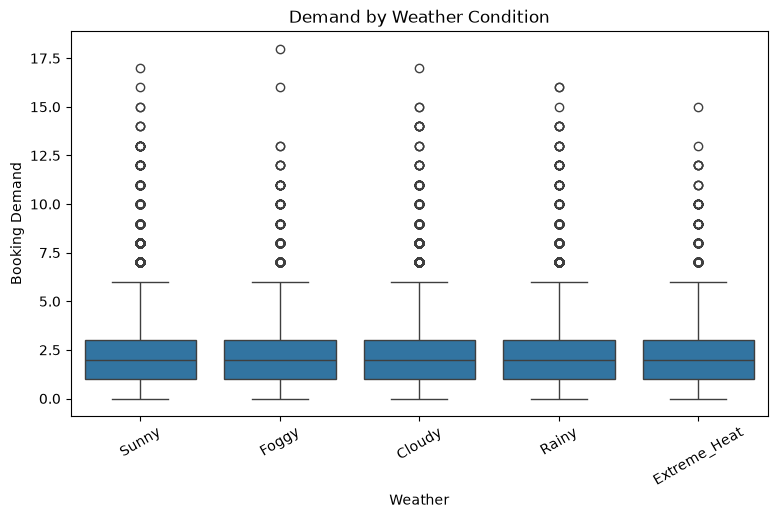

In [71]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="weather_condition",
    y="bookings_demand"
)

plt.title("Demand by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Booking Demand")
plt.xticks(rotation=30)
plt.show()

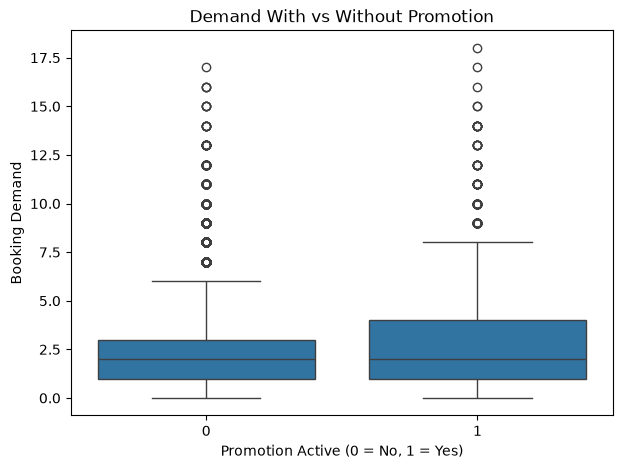

In [72]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="promo_active",
    y="bookings_demand"
)

plt.title("Demand With vs Without Promotion")
plt.xlabel("Promotion Active (0 = No, 1 = Yes)")
plt.ylabel("Booking Demand")
plt.show()

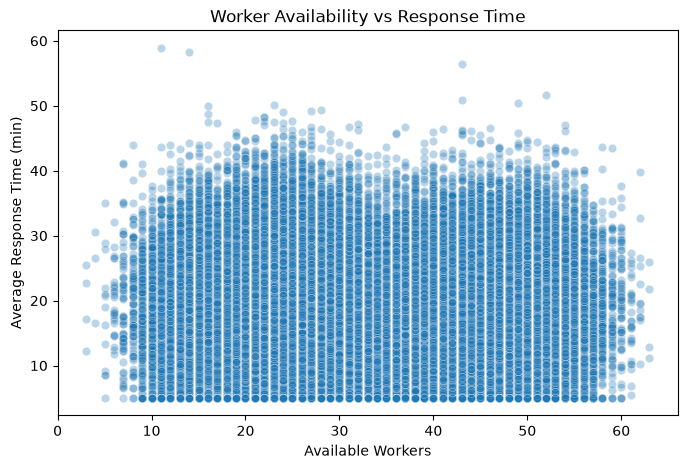

In [73]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="num_available_workers",
    y="avg_response_time_min",
    alpha=0.3
)

plt.title("Worker Availability vs Response Time")
plt.xlabel("Available Workers")
plt.ylabel("Average Response Time (min)")
plt.show()

In [74]:
# ==========================================
# FEATURE ENGINEERING
# ==========================================

In [75]:
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(
    ["zone_id", "service_type", "date"]
).reset_index(drop=True)

In [76]:
df["year"] = df["date"].dt.year
df["day_of_month"] = df["date"].dt.day
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["quarter"] = df["date"].dt.quarter

In [77]:
group_cols = ["zone_id", "service_type"]

df["lag_1"] = (
    df.groupby(group_cols)["bookings_demand"]
      .shift(1)
)

df["lag_7"] = (
    df.groupby(group_cols)["bookings_demand"]
      .shift(7)
)

In [78]:
df["rolling_7"] = (
    df.groupby(group_cols)["bookings_demand"]
      .transform(lambda x: x.shift(1).rolling(7).mean())
)

In [79]:
df["rolling_14"] = (
    df.groupby(group_cols)["bookings_demand"]
      .transform(lambda x: x.shift(1).rolling(14).mean())
)

In [80]:
df["rolling_30"] = (
    df.groupby(group_cols)["bookings_demand"]
      .transform(lambda x: x.shift(1).rolling(30).mean())
)

In [81]:
df["worker_demand_ratio"] = (
    df["num_available_workers"] /
    (df["past_7day_avg_bookings"] + 1)
)

In [82]:
df.head(15)

,date,day_of_week,is_weekend,month,is_holiday_or_festival,zone_id,zone_name,zone_density_tier,service_type,price_tier,...,year,day_of_month,week_of_year,quarter,lag_1,lag_7,rolling_7,rolling_14,rolling_30,worker_demand_ratio
0,2023-01-01,Sunday,1,1,0,Z01,Riverside Sector,High,Babysitting/Childcare,Medium,...,2023,1,52,1,NaN,NaN,NaN,NaN,NaN,7.000000
1,2023-01-02,Monday,0,1,0,Z01,Riverside Sector,High,Babysitting/Childcare,Medium,...,2023,2,1,1,4.0,NaN,NaN,NaN,NaN,2.200000
2,2023-01-03,Tuesday,0,1,0,Z01,Riverside Sector,High,Babysitting/Childcare,Medium,...,2023,3,1,1,1.0,NaN,NaN,NaN,NaN,6.571429
3,2023-01-04,Wednesday,0,1,0,Z01,Riverside Sector,High,Babysitting/Childcare,Medium,...,2023,4,1,1,1.0,NaN,NaN,NaN,NaN,5.333333
4,2023-01-05,Thursday,0,1,0,Z01,Riverside Sector,High,Babysitting/Childcare,Medium,...,2023,5,1,1,1.0,NaN,NaN,NaN,NaN,6.909091
5,2023-01-06,Friday,0,1,0,Z01,Riverside Sector,High,Babysitting/Childcare,Medium,...,2023,6,1,1,1.0,NaN,NaN,NaN,NaN,5.769231
6,2023-01-07,Saturday,1,1,0,Z01,Riverside Sector,High,Babysitting/Childcare,Medium,...,2023,7,1,1,5.0,NaN,NaN,NaN,NaN,4.100946
7,2023-01-08,Sunday,1,1,0,Z01,Riverside Sector,High,Babysitting/Childcare,Medium,...,2023,8,1,1,1.0,4.0,2.000000,NaN,NaN,4.000000
8,2023-01-09,Monday,0,1,0,Z01,Riverside Sector,High,Babysitting/Childcare,Medium,...,2023,9,2,1,2.0,1.0,1.714286,NaN,NaN,5.535055
9,2023-01-10,Tuesday,0,1,0,Z01,Riverside Sector,High,Babysitting/Childcare,Medium,...,2023,10,2,1,3.0,1.0,2.000000,NaN,NaN,5.333333


In [83]:
df.isnull().sum().sort_values(ascending=False)

rolling_30                2400
rolling_14                1120
rolling_7                  560
lag_7                      560
lag_1                       80
date                         0
past_7day_avg_bookings       0
quarter                      0
week_of_year                 0
day_of_month                 0
year                         0
bookings_demand              0
cancellation_rate            0
avg_response_time_min        0
promo_active                 0
day_of_week                  0
avg_zone_worker_rating       0
num_available_workers        0
temperature_c                0
weather_condition            0
price_tier                   0
service_type                 0
zone_density_tier            0
zone_name                    0
zone_id                      0
is_holiday_or_festival       0
month                        0
is_weekend                   0
worker_demand_ratio          0
dtype: int64

In [84]:
df_model = df.dropna().copy()

In [85]:
print("Original rows:", len(df))
print("Rows for modeling:", len(df_model))

Original rows: 58400
Rows for modeling: 56000


In [86]:
numeric_cols = [
    "is_weekend",
    "month",
    "is_holiday_or_festival",
    "temperature_c",
    "num_available_workers",
    "avg_zone_worker_rating",
    "promo_active",
    "past_7day_avg_bookings",
    "avg_response_time_min",
    "cancellation_rate",
    "lag_1",
    "lag_7",
    "rolling_7",
    "rolling_14",
    "rolling_30",
    "worker_demand_ratio",
    "bookings_demand"
]

correlation = (
    df_model[numeric_cols]
    .corr()["bookings_demand"]
    .sort_values(ascending=False)
)

correlation

bookings_demand           1.000000
rolling_30                0.540633
rolling_14                0.530393
past_7day_avg_bookings    0.506754
rolling_7                 0.506752
lag_7                     0.381812
lag_1                     0.347551
is_weekend                0.183114
promo_active              0.079515
month                     0.047449
is_holiday_or_festival    0.034750
cancellation_rate         0.004948
temperature_c            -0.003930
avg_zone_worker_rating   -0.022624
num_available_workers    -0.029434
avg_response_time_min    -0.070667
worker_demand_ratio      -0.309630
Name: bookings_demand, dtype: float64

In [87]:
# ==========================================
# TIME-BASED TRAIN / TEST SPLIT
# ==========================================

train_end = "2024-09-30"

train = df_model[df_model["date"] <= train_end].copy()
test = df_model[df_model["date"] > train_end].copy()

print("Training data:")
print(train["date"].min(), "→", train["date"].max())
print("Rows:", len(train))

print("\nTest data:")
print(test["date"].min(), "→", test["date"].max())
print("Rows:", len(test))

Training data:
2023-01-31 00:00:00 → 2024-09-30 00:00:00
Rows: 48720

Test data:
2024-10-01 00:00:00 → 2024-12-30 00:00:00
Rows: 7280


In [88]:
features = [
    "day_of_week",
    "is_weekend",
    "month",
    "is_holiday_or_festival",
    "zone_id",
    "zone_density_tier",
    "service_type",
    "price_tier",
    "weather_condition",
    "temperature_c",
    "num_available_workers",
    "avg_zone_worker_rating",
    "promo_active",
    "past_7day_avg_bookings",
    "avg_response_time_min",
    "cancellation_rate",
    "lag_1",
    "lag_7",
    "rolling_7",
    "rolling_14",
    "rolling_30",
    "worker_demand_ratio"
]

target = "bookings_demand"

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (48720, 22)
X_test: (7280, 22)


In [89]:
# ==========================================
# PREPROCESSING
# ==========================================

categorical_features = [
    "day_of_week",
    "zone_id",
    "zone_density_tier",
    "service_type",
    "price_tier",
    "weather_condition"
]

numerical_features = [
    "is_weekend",
    "month",
    "is_holiday_or_festival",
    "temperature_c",
    "num_available_workers",
    "avg_zone_worker_rating",
    "promo_active",
    "past_7day_avg_bookings",
    "avg_response_time_min",
    "cancellation_rate",
    "lag_1",
    "lag_7",
    "rolling_14",
    "rolling_30",
    "worker_demand_ratio"
]

In [90]:
print("Categorical:", len(categorical_features))
print("Numerical:", len(numerical_features))
print("Total:", len(categorical_features) + len(numerical_features))

Categorical: 6
Numerical: 15
Total: 21


In [91]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)

In [92]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Before preprocessing:", X_train.shape)
print("After preprocessing:", X_train_processed.shape)

Before preprocessing: (48720, 22)
After preprocessing: (48720, 51)


In [93]:
# ==========================================
# MODEL 1 — RANDOM FOREST BASELINE
# ==========================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [94]:
y_pred_rf = rf_model.predict(X_test_processed)

In [95]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)

Random Forest Results
---------------------
MAE : 1.2661758241758243
RMSE: 1.640177225917243


In [96]:
import xgboost as xgb

print(xgb.__version__)

3.4.1


In [97]:
# ==========================================
# MODEL 2 — XGBOOST
# ==========================================

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_processed,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [98]:
y_pred_xgb = xgb_model.predict(X_test_processed)

In [99]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, y_pred_xgb)
)

print("XGBoost Results")
print("----------------")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)

XGBoost Results
----------------
MAE : 1.228071689605713
RMSE: 1.6132269381416624


In [100]:
import pandas as pd

importance = pd.Series(
    xgb_model.feature_importances_,
    index=preprocessor.get_feature_names_out()
)

importance = importance.sort_values(ascending=False)

print(importance.head(20))

num__is_weekend                            0.153455
num__rolling_30                            0.111996
num__rolling_14                            0.070371
num__promo_active                          0.035714
cat__service_type_Home Cleaning            0.035587
cat__service_type_Cooking/Catering         0.023233
num__is_holiday_or_festival                0.023165
cat__day_of_week_Saturday                  0.023103
cat__service_type_Babysitting/Childcare    0.022527
cat__price_tier_High                       0.022244
cat__zone_density_tier_Low                 0.021917
cat__zone_density_tier_High                0.021184
cat__price_tier_Medium                     0.020458
cat__day_of_week_Sunday                    0.019514
cat__service_type_Elderly Care             0.019215
cat__service_type_Plumbing Repair          0.018674
cat__service_type_Electrical Repair        0.017599
cat__service_type_Gardening/Landscaping    0.014456
cat__price_tier_Low                        0.014128
cat__service

In [101]:
# ==========================================
# AGGREGATED FEATURE IMPORTANCE
# ==========================================

importance_df = pd.DataFrame({
    "feature": preprocessor.get_feature_names_out(),
    "importance": xgb_model.feature_importances_
})

def get_original_feature(feature):
    if feature.startswith("num__"):
        return feature.replace("num__", "")
    
    if feature.startswith("cat__"):
        feature = feature.replace("cat__", "")
        
        for col in categorical_features:
            if feature.startswith(col + "_"):
                return col
    
    return feature


importance_df["original_feature"] = (
    importance_df["feature"].apply(get_original_feature)
)

aggregated_importance = (
    importance_df
    .groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
)

print(aggregated_importance)

original_feature
service_type              0.164675
is_weekend                0.153455
rolling_30                0.111996
zone_id                   0.096064
day_of_week               0.075676
rolling_14                0.070371
price_tier                0.056829
zone_density_tier         0.055860
weather_condition         0.045456
promo_active              0.035714
is_holiday_or_festival    0.023165
avg_zone_worker_rating    0.012090
past_7day_avg_bookings    0.011631
worker_demand_ratio       0.011619
lag_1                     0.011074
cancellation_rate         0.010905
month                     0.010896
lag_7                     0.010783
temperature_c             0.010662
avg_response_time_min     0.010611
num_available_workers     0.010467
Name: importance, dtype: float32


In [103]:
baseline_mae = 1.228071689605713
baseline_rmse = 1.6132269381416624

print("Baseline XGBoost")
print("----------------")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)

Baseline XGBoost
----------------
MAE : 1.228071689605713
RMSE: 1.6132269381416624


In [104]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from xgboost import XGBRegressor

In [105]:
tscv = TimeSeriesSplit(n_splits=5)

print(tscv)

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


In [106]:
param_grid = {
    "n_estimators": [200, 300, 400, 500, 600],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
}

In [107]:
xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

In [108]:
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [109]:
random_search.fit(
    X_train_processed,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best e

In [110]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV MAE:")
print(-random_search.best_score_)

Best Parameters:
{'subsample': 1.0, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.9}

Best CV MAE:
1.1672390222549438


In [111]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

best_xgb = random_search.best_estimator_

y_pred_tuned = best_xgb.predict(X_test_processed)

tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print("Tuned XGBoost Results")
print("---------------------")
print("MAE :", tuned_mae)
print("RMSE:", tuned_rmse)

Tuned XGBoost Results
---------------------
MAE : 1.234058141708374
RMSE: 1.6148413257183891


In [112]:
# ==========================================
# ACTUAL vs PREDICTED
# ==========================================

evaluation = test[["date", "zone_id", "service_type"]].copy()

evaluation["actual"] = y_test.values
evaluation["predicted"] = y_pred_xgb

evaluation["error"] = (
    evaluation["actual"] - evaluation["predicted"]
)

evaluation["absolute_error"] = (
    evaluation["error"].abs()
)

evaluation.head(10)

,date,zone_id,service_type,actual,predicted,error,absolute_error
639,2024-10-01,Z01,Babysitting/Childcare,6,2.360282,3.639718,3.639718
640,2024-10-02,Z01,Babysitting/Childcare,5,2.926103,2.073897,2.073897
641,2024-10-03,Z01,Babysitting/Childcare,3,2.297921,0.702079,0.702079
642,2024-10-04,Z01,Babysitting/Childcare,1,2.024841,-1.024841,1.024841
643,2024-10-05,Z01,Babysitting/Childcare,2,4.053144,-2.053144,2.053144
644,2024-10-06,Z01,Babysitting/Childcare,6,4.407163,1.592837,1.592837
645,2024-10-07,Z01,Babysitting/Childcare,1,2.338122,-1.338122,1.338122
646,2024-10-08,Z01,Babysitting/Childcare,2,2.405624,-0.405624,0.405624
647,2024-10-09,Z01,Babysitting/Childcare,3,2.604947,0.395053,0.395053
648,2024-10-10,Z01,Babysitting/Childcare,3,2.448600,0.551400,0.551400


In [113]:
# ==========================================
# LARGEST PREDICTION ERRORS
# ==========================================

largest_errors = evaluation.sort_values(
    "absolute_error",
    ascending=False
)

largest_errors.head(15)

,date,zone_id,service_type,actual,predicted,error,absolute_error
30590,2024-10-22,Z06,Cooking/Catering,11,1.916430,9.083570,9.083570
10149,2024-10-21,Z02,Home Cleaning,14,5.283933,8.716067,8.716067
51090,2024-12-21,Z09,Home Cleaning,16,7.370292,8.629708,8.629708
21828,2024-10-20,Z04,Home Cleaning,16,8.071185,7.928815,7.928815
51757,2024-10-19,Z09,Laundry/Ironing,12,4.408741,7.591259,7.591259
10168,2024-11-09,Z02,Home Cleaning,16,8.475145,7.524855,7.524855
56889,2024-11-10,Z10,Home Cleaning,11,3.671159,7.328841,7.328841
33550,2024-12-01,Z06,Home Cleaning,11,3.699256,7.300744,7.300744
56910,2024-12-01,Z10,Home Cleaning,11,3.825456,7.174544,7.174544
40076,2024-10-18,Z07,Laundry/Ironing,10,2.896508,7.103492,7.103492


In [114]:
print("Mean Error:", evaluation["error"].mean())
print("Mean Absolute Error:", evaluation["absolute_error"].mean())

Mean Error: 0.14692354076183758
Mean Absolute Error: 1.2280717125960758


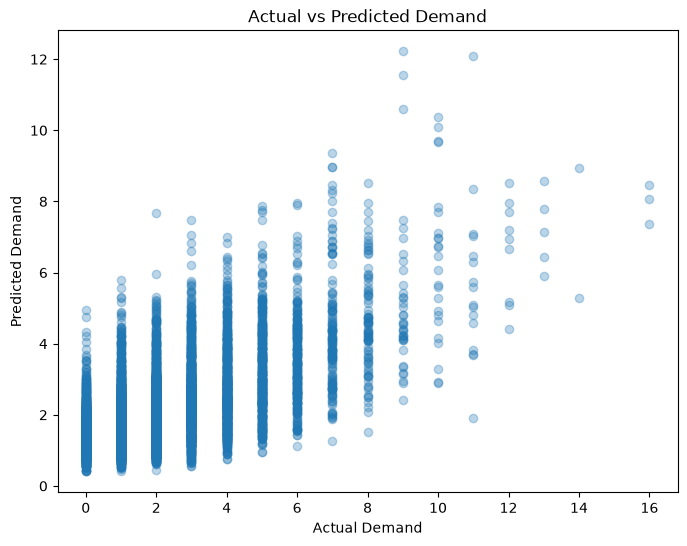

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    evaluation["actual"],
    evaluation["predicted"],
    alpha=0.3
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")

plt.show()

In [116]:
service_error = (
    evaluation
    .groupby("service_type")
    .agg(
        MAE=("absolute_error", "mean"),
        Mean_Error=("error", "mean"),
        Actual_Demand=("actual", "mean")
    )
    .sort_values("MAE", ascending=False)
)

service_error

,MAE,Mean_Error,Actual_Demand
service_type,,,
Home Cleaning,1.726903,0.445414,4.527473
Laundry/Ironing,1.384725,0.224600,3.136264
Babysitting/Childcare,1.331040,0.151786,2.686813
Cooking/Catering,1.241186,0.181923,2.298901
Plumbing Repair,1.177317,-0.015418,2.196703
Electrical Repair,1.074636,0.029697,1.912088
Elderly Care,0.944674,0.059589,1.345055
Gardening/Landscaping,0.944093,0.097798,1.410989


In [117]:
zone_error = (
    evaluation
    .groupby("zone_id")
    .agg(
        MAE=("absolute_error", "mean"),
        Mean_Error=("error", "mean"),
        Actual_Demand=("actual", "mean")
    )
    .sort_values("MAE", ascending=False)
)

zone_error

,MAE,Mean_Error,Actual_Demand
zone_id,,,
Z09,1.469598,0.166887,3.277473
Z01,1.419225,0.235129,3.100275
Z02,1.369475,0.239060,3.130495
Z03,1.240283,0.104841,2.388736
Z06,1.231734,0.194231,2.344780
Z04,1.213009,0.074440,2.436813
Z07,1.211016,0.132818,2.468407
Z10,1.070845,0.074755,1.748626
Z05,1.060154,0.085066,1.916209


In [118]:
high_demand = evaluation[evaluation["actual"] >= 8]

print("High-demand cases:", len(high_demand))
print("High-demand MAE:", high_demand["absolute_error"].mean())
print("High-demand Mean Error:", high_demand["error"].mean())

High-demand cases: 184
High-demand MAE: 4.056787089161251
High-demand Mean Error: 3.95399859936341


In [119]:
normal_demand = evaluation[evaluation["actual"] < 8]

print("Normal-demand cases:", len(normal_demand))
print("Normal-demand MAE:", normal_demand["absolute_error"].mean())

Normal-demand cases: 7096
Normal-demand MAE: 1.154722835864397


In [120]:
high_demand = evaluation[evaluation["actual"] >= 8].copy()

high_demand.head(20)

,date,zone_id,service_type,actual,predicted,error,absolute_error
679,2024-11-10,Z01,Babysitting/Childcare,8,3.526997,4.473003,4.473003
1387,2024-10-19,Z01,Cooking/Catering,9,4.112104,4.887896,4.887896
2846,2024-10-18,Z01,Electrical Repair,8,2.799191,5.200809,5.200809
4294,2024-10-06,Z01,Home Cleaning,12,8.522193,3.477807,3.477807
4295,2024-10-07,Z01,Home Cleaning,8,5.888350,2.111650,2.111650
4300,2024-10-12,Z01,Home Cleaning,9,7.245373,1.754627,1.754627
4303,2024-10-15,Z01,Home Cleaning,9,4.614967,4.385033,4.385033
4307,2024-10-19,Z01,Home Cleaning,8,6.907998,1.092002,1.092002
4311,2024-10-23,Z01,Home Cleaning,9,4.540644,4.459356,4.459356
4314,2024-10-26,Z01,Home Cleaning,11,6.471990,4.528010,4.528010


In [121]:
high_service = (
    high_demand
    .groupby("service_type")
    .agg(
        Cases=("actual", "count"),
        MAE=("absolute_error", "mean"),
        Mean_Error=("error", "mean"),
        Actual_Demand=("actual", "mean"),
        Predicted_Demand=("predicted", "mean")
    )
    .sort_values("MAE", ascending=False)
)

high_service

,Cases,MAE,Mean_Error,Actual_Demand,Predicted_Demand
service_type,,,,,
Electrical Repair,1,5.200809,5.200809,8.000000,2.799191
Laundry/Ironing,18,4.977551,4.977551,9.166667,4.189116
Plumbing Repair,5,4.697853,4.697853,8.000000,3.302146
Babysitting/Childcare,23,4.660312,4.660312,8.521739,3.861428
Cooking/Catering,20,4.614161,4.614161,8.700000,4.085839
Home Cleaning,117,3.664038,3.502388,9.572650,6.070262


In [122]:
high_zone = (
    high_demand
    .groupby("zone_id")
    .agg(
        Cases=("actual", "count"),
        MAE=("absolute_error", "mean"),
        Mean_Error=("error", "mean"),
        Actual_Demand=("actual", "mean"),
        Predicted_Demand=("predicted", "mean")
    )
    .sort_values("MAE", ascending=False)
)

high_zone

,Cases,MAE,Mean_Error,Actual_Demand,Predicted_Demand
zone_id,,,,,
Z10,3,6.712671,6.712671,10.333333,3.620663
Z08,2,5.357086,5.357086,8.000000,2.642914
Z06,16,5.203839,5.203839,9.125000,3.921161
Z05,7,4.186671,4.186671,8.142857,3.956186
Z01,32,4.084669,4.084669,9.312500,5.227831
Z07,14,4.068175,4.068175,8.642857,4.574683
Z03,20,3.961018,3.961018,8.400000,4.438982
Z04,23,3.912423,3.912423,9.652174,5.739751
Z09,39,3.825281,3.798260,9.512821,5.714561


In [123]:
high_analysis = test.loc[high_demand.index].copy()

high_analysis["predicted"] = high_demand["predicted"].values
high_analysis["error"] = high_demand["error"].values
high_analysis["absolute_error"] = high_demand["absolute_error"].values

In [124]:
high_analysis[
    [
        "date",
        "zone_id",
        "service_type",
        "is_weekend",
        "is_holiday_or_festival",
        "promo_active",
        "past_7day_avg_bookings",
        "lag_1",
        "lag_7",
        "rolling_14",
        "rolling_30",
        "bookings_demand",
        "predicted"
    ]
].sort_values("bookings_demand", ascending=False).head(30)

,date,zone_id,service_type,is_weekend,is_holiday_or_festival,promo_active,past_7day_avg_bookings,lag_1,lag_7,rolling_14,rolling_30,bookings_demand,predicted
10168,2024-11-09,Z02,Home Cleaning,1,0,0,6.43,3.0,9.0,6.571429,6.600000,16,8.475145
51090,2024-12-21,Z09,Home Cleaning,1,0,1,4.86,5.0,7.0,4.571429,5.033333,16,7.370292
21828,2024-10-20,Z04,Home Cleaning,1,0,0,7.57,14.0,10.0,6.357143,6.133333,16,8.071185
10149,2024-10-21,Z02,Home Cleaning,0,0,1,7.43,9.0,9.0,6.357143,6.233333,14,5.283933
21827,2024-10-19,Z04,Home Cleaning,1,0,1,6.29,3.0,5.0,6.071429,5.933333,14,8.931685
4315,2024-10-27,Z01,Home Cleaning,1,0,0,6.57,11.0,7.0,6.285714,5.933333,13,7.154439
51034,2024-10-26,Z09,Home Cleaning,1,0,0,7.43,7.0,8.0,6.642857,5.766667,13,7.783733
4321,2024-11-02,Z01,Home Cleaning,1,0,0,8.29,7.0,11.0,7.214286,6.433333,13,6.424842
51035,2024-10-27,Z09,Home Cleaning,1,0,0,8.14,13.0,12.0,6.642857,6.000000,13,8.584481
51020,2024-10-12,Z09,Home Cleaning,1,0,0,4.71,4.0,8.0,4.714286,5.066667,13,5.913156


In [125]:
group_cols = ["zone_id", "service_type"]

# Additional lags
df["lag_14"] = df.groupby(group_cols)["bookings_demand"].shift(14)
df["lag_28"] = df.groupby(group_cols)["bookings_demand"].shift(28)

# Rolling maximums
df["rolling_max_7"] = df.groupby(group_cols)["bookings_demand"].transform(
    lambda x: x.shift(1).rolling(7).max()
)

df["rolling_max_14"] = df.groupby(group_cols)["bookings_demand"].transform(
    lambda x: x.shift(1).rolling(14).max()
)

# Rolling standard deviation
df["rolling_std_7"] = df.groupby(group_cols)["bookings_demand"].transform(
    lambda x: x.shift(1).rolling(7).std()
)

df["rolling_std_14"] = df.groupby(group_cols)["bookings_demand"].transform(
    lambda x: x.shift(1).rolling(14).std()
)

# Demand momentum
df["demand_change_1"] = (
    df["lag_1"] - df["lag_7"]
)

df["demand_change_7"] = (
    df["lag_7"] - df["lag_14"]
)

df_model = df.dropna().copy()

In [127]:
numerical_features = [
    "is_weekend",
    "month",
    "is_holiday_or_festival",
    "temperature_c",
    "num_available_workers",
    "avg_zone_worker_rating",
    "promo_active",
    "past_7day_avg_bookings",
    "avg_response_time_min",
    "cancellation_rate",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_14",
    "rolling_30",
    "rolling_max_7",
    "rolling_max_14",
    "rolling_std_7",
    "rolling_std_14",
    "demand_change_1",
    "demand_change_7",
    "worker_demand_ratio"
]

In [128]:
preprocessor_v2 = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

In [129]:
train_end = "2024-09-30"

train_v2 = df_model[df_model["date"] <= train_end].copy()
test_v2 = df_model[df_model["date"] > train_end].copy()

X_train_v2 = preprocessor_v2.fit_transform(
    train_v2[categorical_features + numerical_features]
)

X_test_v2 = preprocessor_v2.transform(
    test_v2[categorical_features + numerical_features]
)

y_train_v2 = train_v2["bookings_demand"]
y_test_v2 = test_v2["bookings_demand"]

In [130]:
xgb_v2 = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_v2.fit(X_train_v2, y_train_v2)

y_pred_v2 = xgb_v2.predict(X_test_v2)

In [131]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_v2 = mean_absolute_error(y_test_v2, y_pred_v2)

rmse_v2 = np.sqrt(
    mean_squared_error(y_test_v2, y_pred_v2)
)

print("V2 MAE:", mae_v2)
print("V2 RMSE:", rmse_v2)

V2 MAE: 1.2323663234710693
V2 RMSE: 1.6162680255684245


In [132]:
high_v2 = test_v2.copy()

high_v2["actual"] = y_test_v2.values
high_v2["predicted"] = y_pred_v2

high_v2 = high_v2[high_v2["actual"] >= 8].copy()

high_v2["error"] = (
    high_v2["actual"] - high_v2["predicted"]
)

high_v2["absolute_error"] = high_v2["error"].abs()

print("High-demand cases:", len(high_v2))
print("High-demand MAE:", high_v2["absolute_error"].mean())
print("High-demand Mean Error:", high_v2["error"].mean())

High-demand cases: 184
High-demand MAE: 4.092998253910438
High-demand Mean Error: 4.05194614050181


In [133]:
train_end = "2024-09-30"

train = df_model[df_model["date"] <= train_end].copy()
test = df_model[df_model["date"] > train_end].copy()

In [134]:
sample_weights = np.where(
    y_train >= 8,
    3.0,
    1.0
)

In [135]:
xgb_weighted = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_weighted.fit(
    X_train_processed,
    y_train,
    sample_weight=sample_weights
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [136]:
y_pred_weighted = xgb_weighted.predict(
    X_test_processed
)

In [137]:
mae_weighted = mean_absolute_error(
    y_test,
    y_pred_weighted
)

rmse_weighted = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_weighted
    )
)

print("Weighted MAE:", mae_weighted)
print("Weighted RMSE:", rmse_weighted)

Weighted MAE: 1.23190438747406
Weighted RMSE: 1.6113004554915982


In [138]:
weighted_eval = test[
    ["date", "zone_id", "service_type"]
].copy()

weighted_eval["actual"] = y_test.values
weighted_eval["predicted"] = y_pred_weighted

weighted_eval["error"] = (
    weighted_eval["actual"]
    - weighted_eval["predicted"]
)

weighted_eval["absolute_error"] = (
    weighted_eval["error"].abs()
)

high_weighted = weighted_eval[
    weighted_eval["actual"] >= 8
]

print(
    "High-demand MAE:",
    high_weighted["absolute_error"].mean()
)

print(
    "High-demand Mean Error:",
    high_weighted["error"].mean()
)

High-demand MAE: 3.75582130058952
High-demand Mean Error: 3.601884479108064


In [139]:
weights_2 = np.where(y_train >= 8, 2.0, 1.0)

xgb_w2 = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_w2.fit(
    X_train_processed,
    y_train,
    sample_weight=weights_2
)

pred_w2 = xgb_w2.predict(X_test_processed)

In [140]:
print("Overall MAE:", mean_absolute_error(y_test, pred_w2))
print("Overall RMSE:", np.sqrt(mean_squared_error(y_test, pred_w2)))

high_mask = y_test.values >= 8

print(
    "High-demand MAE:",
    mean_absolute_error(
        y_test.values[high_mask],
        pred_w2[high_mask]
    )
)

print(
    "High-demand Mean Error:",
    np.mean(
        y_test.values[high_mask] -
        pred_w2[high_mask]
    )
)

Overall MAE: 1.2294363975524902
Overall RMSE: 1.610866929144824
High-demand MAE: 3.8713438510894775
High-demand Mean Error: 3.7172357278025667


In [141]:
weights_5 = np.where(y_train >= 8, 5.0, 1.0)

xgb_w5 = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_w5.fit(
    X_train_processed,
    y_train,
    sample_weight=weights_5
)

pred_w5 = xgb_w5.predict(X_test_processed)

In [142]:
print("Overall MAE:", mean_absolute_error(y_test, pred_w5))
print("Overall RMSE:", np.sqrt(mean_squared_error(y_test, pred_w5)))

print(
    "High-demand MAE:",
    mean_absolute_error(
        y_test.values[high_mask],
        pred_w5[high_mask]
    )
)

print(
    "High-demand Mean Error:",
    np.mean(
        y_test.values[high_mask] -
        pred_w5[high_mask]
    )
)

Overall MAE: 1.236932396888733
Overall RMSE: 1.6233874903476184
High-demand MAE: 3.7337393760681152
High-demand Mean Error: 3.562564996921498


In [143]:
xgb_final = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

final_weights = np.where(
    y_train >= 8,
    3.0,
    1.0
)

xgb_final.fit(
    X_train_processed,
    y_train,
    sample_weight=final_weights
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [144]:
final_eval = test[
    ["date", "zone_id", "service_type"]
].copy()

final_eval["actual"] = y_test.values
final_eval["predicted"] = y_pred_weighted

final_eval["error"] = (
    final_eval["actual"] - final_eval["predicted"]
)

final_eval["absolute_error"] = (
    final_eval["error"].abs()
)

In [145]:
final_eval.sort_values(
    "absolute_error",
    ascending=False
).head(20)

,date,zone_id,service_type,actual,predicted,error,absolute_error
30590,2024-10-22,Z06,Cooking/Catering,11,1.880495,9.119505,9.119505
10149,2024-10-21,Z02,Home Cleaning,14,5.260297,8.739703,8.739703
51090,2024-12-21,Z09,Home Cleaning,16,8.071651,7.928349,7.928349
10168,2024-11-09,Z02,Home Cleaning,16,8.260739,7.739261,7.739261
51757,2024-10-19,Z09,Laundry/Ironing,12,4.696865,7.303135,7.303135
21828,2024-10-20,Z04,Home Cleaning,16,8.903124,7.096876,7.096876
4321,2024-11-02,Z01,Home Cleaning,13,6.017436,6.982564,6.982564
30595,2024-10-27,Z06,Cooking/Catering,12,5.112998,6.887002,6.887002
5087,2024-12-08,Z01,Laundry/Ironing,10,3.135260,6.864740,6.864740
56889,2024-11-10,Z10,Home Cleaning,11,4.168431,6.831569,6.831569


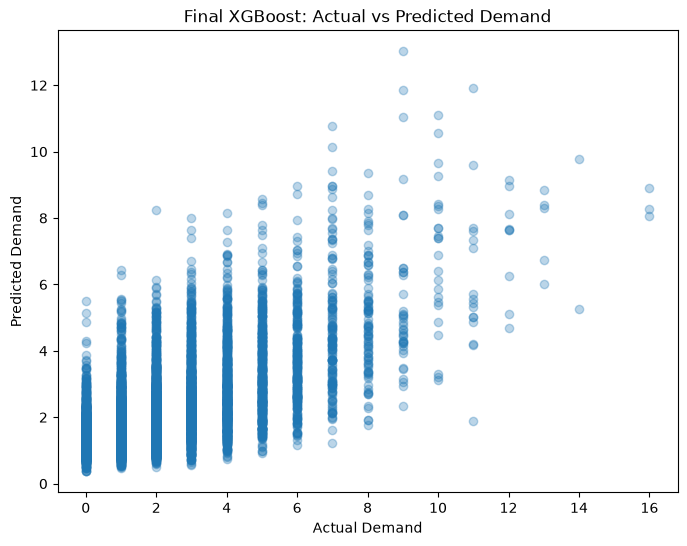

In [146]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    final_eval["actual"],
    final_eval["predicted"],
    alpha=0.3
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Final XGBoost: Actual vs Predicted Demand")

plt.show()

In [147]:
print(
    "Minimum prediction:",
    final_eval["predicted"].min()
)

print(
    "Negative predictions:",
    (final_eval["predicted"] < 0).sum()
)

Minimum prediction: 0.3657326
Negative predictions: 0


In [148]:
print(
    "Actual range:",
    y_test.min(),
    "to",
    y_test.max()
)

print(
    "Prediction range:",
    final_eval["predicted"].min(),
    "to",
    final_eval["predicted"].max()
)

Actual range: 0 to 16
Prediction range: 0.3657326 to 13.01604


In [149]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    xgb_weighted,
    "../models/xgb_demand_model.pkl"
)

joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!


In [150]:
import os

print(os.path.exists("../models/xgb_demand_model.pkl"))
print(os.path.exists("../models/preprocessor.pkl"))

True
True
